In [1]:
#Algorithm - Autoregressive Integrated Moving Average - (ARIMA)

In [2]:
#1.IMPORTING PANDAS LIBRARY

import pandas as pd
# import → Python keyword used to bring in a library/module
# pandas → open-source library for data manipulation and analysis
# as → keyword used to assign an alias (short name)
# pd → alias used to refer to pandas throughout the code

# Summary: This line imports the pandas library and gives it the shorter name "pd" for easy use later in the notebook.

In [3]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [4]:
#2.IMPORTING NSEPY AND DATETIME LIBRARIES

from nsepy import get_history as gh
# from → keyword used to import a specific part of a module
# nsepy → library used to fetch historical stock data from NSE (India)
# import → keyword used to bring in a library/module/function
# get_history → function used to fetch historical stock price data
# as → keyword used to assign an alias (short name)
# gh → alias used to refer to get_history function

import datetime as dt
# import → keyword used to bring in a library/module
# datetime → built-in module used to work with dates and times
# as → keyword used to assign an alias (short name)
# dt → alias used to refer to datetime module

# Summary: This line imports the get_history function from nsepy (renamed as gh) to fetch stock data, and the datetime module (renamed as dt) 
# to handle date values.

In [6]:
#3.FETCHING STOCK DATA USING YFINANCE

import yfinance as yf
# import → keyword used to bring in a library/module
# yfinance → library used to fetch stock market data from Yahoo Finance
# as → keyword used to assign an alias (short name)
# yf → alias used to refer to yfinance library

stk_data = yf.download("TCS.NS", start='2021-09-01', end='2022-02-04')
# stk_data → variable to store the fetched stock data
# yf.download → function used to download historical stock data
# "TCS.NS" → stock symbol for TCS (.NS suffix required for NSE stocks on Yahoo Finance)
# start → parameter specifying the start date (as string 'YYYY-MM-DD')
# end → parameter specifying the end date (as string 'YYYY-MM-DD')

# Summary: This line imports yfinance and fetches historical stock data for TCS.NS between the given dates, storing it in stk_data.

[*********************100%***********************]  1 of 1 completed


In [7]:
#4.SELECTING REQUIRED COLUMNS FROM STOCK DATA

stk_data = stk_data[["Open","High","Low","Close"]]
# stk_data → variable holding the stock data DataFrame
# [["Open","High","Low","Close"]] → selects only these specific columns from the DataFrame
# "Open" → opening price of the stock for each day
# "High" → highest price of the stock for each day
# "Low" → lowest price of the stock for each day
# "Close" → closing price of the stock for each day

# Summary: This line filters stk_data to keep only the Open, High, Low, and Close columns.

In [8]:
#5.SCALING THE TARGET COLUMN USING MINMAXSCALER

from sklearn.preprocessing import MinMaxScaler
# from → keyword used to import a specific part of a module
# sklearn.preprocessing → module containing data preprocessing tools
# import → keyword used to bring in a library/module/function
# MinMaxScaler → class used to scale features to a fixed range (default 0 to 1)

Ms = MinMaxScaler()
# Ms → variable to store the MinMaxScaler object
# MinMaxScaler() → creates an instance of the scaler

data1 = Ms.fit_transform(stk_data[["Close"]])
# data1 → variable to store the scaled data
# Ms.fit_transform → function that fits the scaler to the data and transforms it
# stk_data[["Close"]] → selects the "Close" column as a DataFrame

print("Len:", data1.shape)
# print → built-in function to display output
# "Len:" → label text for the printed output
# data1.shape → returns the dimensions (rows, columns) of the scaled data

# Summary: This line scales the "Close" column values between 0 and 1 using MinMaxScaler and prints the shape of the resulting scaled data.

Len: (107, 1)


In [9]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [10]:
#6.TRAINING ARIMA MODEL WITH DIFFERENT ORDER COMBINATIONS

orders = [(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
# orders → variable storing a list of ARIMA order combinations to test
# (p,d,q) → p=autoregressive terms, d=differencing, q=moving average terms

#orderslist=[]
# orderslist → commented-out empty list (currently unused, likely meant to store tested orders)

#rscorelist=[]
# rscorelist → commented-out empty list (currently unused, likely meant to store R-squared scores)

for i in orders:
# for → keyword used to start a loop
# i → loop variable representing each order tuple
# in orders → iterates through the orders list

    #orderslist.append(i)
    # orderslist.append(i) → commented-out line that would store the current order

    from statsmodels.tsa.arima.model import ARIMA
    # from → keyword used to import a specific part of a module
    # statsmodels.tsa.arima.model → module containing ARIMA modeling tools
    # ARIMA → class used to build AutoRegressive Integrated Moving Average models

    model = ARIMA(data1, order=i)
    # model → variable to store the ARIMA model object
    # ARIMA → class used to create the model
    # data1 → scaled data used to fit the model
    # order=i → current ARIMA order from the loop iteration

    model_fit = model.fit()
    # model_fit → variable to store the fitted model
    # model.fit() → function that trains the ARIMA model on data1

    # make prediction
    y_pred = model_fit.predict(0, len(data1)-1)
    # y_pred → variable to store predicted values
    # model_fit.predict → function used to generate predictions
    # 0 → starting index for prediction (beginning of dataset)
    # len(data1)-1 → ending index for prediction (end of dataset)

    #print(y_pred)
    # print(y_pred) → commented-out line to display predicted values

    from stockFunctions import rmsemape
    # from → keyword used to import a specific part of a module
    # stockFunctions → custom user-defined module
    # rmsemape → custom function used to calculate RMSE and MAPE

    rmsemape(data1, y_pred)
    # rmsemape → calls the custom function to print RMSE and MAPE
    # data1 → actual scaled values
    # y_pred → predicted values

# Summary: This loop trains an ARIMA model on data1 for each order combination in the list, predicts values across the full dataset, 
# and prints the RMSE/MAPE performance metrics for comparison.

C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE-Testset: 0.09244433420721064
maPe-Testset: 842663121556.9363
RMSE-Testset: 0.09213247576015919
maPe-Testset: 1111317626926.3


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE-Testset: 0.11260377649922396
maPe-Testset: 1283753821532.7026
RMSE-Testset: 0.09454994740860465
maPe-Testset: 373198812243.1351


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


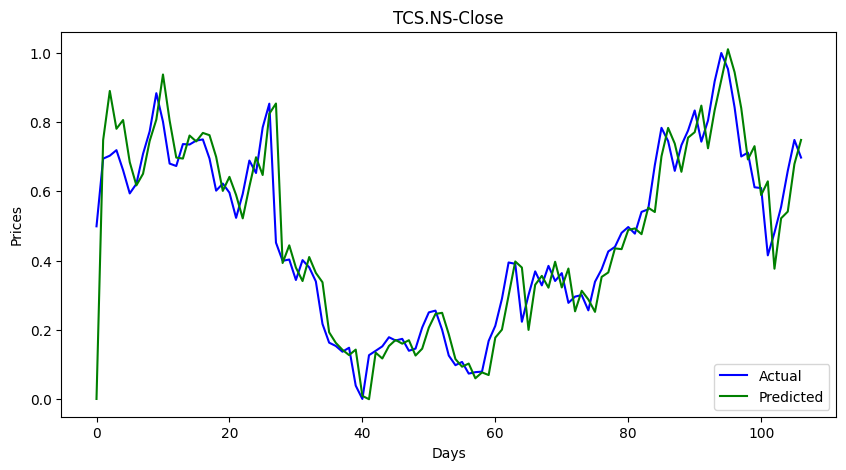

In [11]:
#7.PLOTTING ACTUAL VS PREDICTED VALUES

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(data1, y_pred, "Actual", "Predicted", "TCS.NS-Close", "Days", "Prices")
# graph → function call to generate the plot
# data1 → actual scaled values to plot
# y_pred → predicted values to plot
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TCS.NS-Close" → title of the graph
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices using the custom graph function, labeled with title and axis names.

In [12]:
#8.CHECKING LENGTH OF SCALED DATA

len(data1)
# len → built-in function used to return the number of items in an object
# data1 → variable holding the scaled "Close" price values

# Summary: This line checks and returns the total number of rows in the scaled dataset data1.

107

In [13]:
#9.CONVERTING ACTUAL DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

aTestNormTable = conversionSingle(data1, ["Close"])
# aTestNormTable → variable to store the converted normalized table
# conversionSingle → function call to reshape data1 into table format
# data1 → scaled actual values
# ["Close"] → column name list used as header

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
# actual_stock_price_test_ori → variable to store the original-scale stock prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# aTestNormTable → normalized table to be converted back to original values

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, ["Close"])
# actual_stock_price_test_oriA → variable to store the final formatted original-scale prices
# conversionSingle → function call to reshape the data into table format again
# actual_stock_price_test_ori → original-scale stock price values
# ["Close"] → column name list used as header

# Summary: This block converts the normalized actual values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

In [14]:
#10.CONVERTING PREDICTED DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

pTestNormTable = conversionSingle(y_pred, ["Close"])
# pTestNormTable → variable to store the converted normalized prediction table
# conversionSingle → function call to reshape y_pred into table format
# y_pred → normalized predicted values
# ["Close"] → column name list used as header

predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
# predicted_stock_price_test_ori → variable to store the original-scale predicted prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# pTestNormTable → normalized table to be converted back to original values

predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, ["Close"])
# predicted_stock_price_test_oriP → variable to store the final formatted original-scale predictions
# conversionSingle → function call to reshape the data into table format again
# predicted_stock_price_test_ori → original-scale predicted price values
# ["Close"] → column name list used as header

# Summary: This block converts the normalized predicted values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

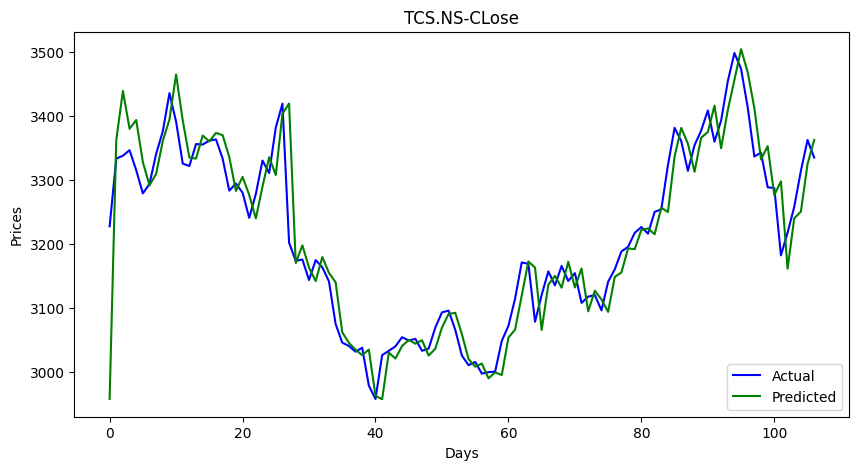

In [15]:
#11.PLOTTING ACTUAL VS PREDICTED VALUES (ORIGINAL SCALE)

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP, "Actual", "Predicted", "TCS.NS-CLose", "Days", "Prices")
# graph → function call to generate the plot
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TCS.NS-CLose" → title of the graph
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices in their original (unscaled) price values using the custom graph function.

In [16]:
#12.CALCULATING RMSE AND MAPE (ORIGINAL SCALE)

from stockFunctions import rmsemape
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# rmsemape → custom function used to calculate RMSE and MAPE

rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)
# rmsemape → function call to compute and print error metrics
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale

# Summary: This line calculates and prints the RMSE and MAPE between actual and predicted stock prices in their original (unscaled) values.

RMSE-Testset: 51.13686353618879
maPe-Testset: 0.010776820184819243


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [17]:
#13.FORECASTING NEXT 3 VALUES

forecast = model_fit.predict(len(data1), len(data1)+3)
# forecast → variable to store the forecasted values
# model_fit.predict → function used to generate predictions from the fitted model
# len(data1) → starting index for forecast (one step beyond available data)
# len(data1)+3 → ending index for forecast (3 steps beyond starting point)

# Summary: This line uses the fitted ARIMA model to forecast the next few values immediately following the available dataset.

In [18]:
#14.DISPLAYING FORECASTED VALUES

forecast
# forecast → variable holding the forecasted values from the ARIMA model

# Summary: This line displays the forecasted values generated by the ARIMA model.

array([0.68800511, 0.69784106, 0.69791402, 0.70034352])

In [19]:
#15.CONVERTING FORECASTED VALUES BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

fTestNormTable = conversionSingle(forecast, ["Closefore"])
# fTestNormTable → variable to store the converted normalized forecast table
# conversionSingle → function call to reshape forecast into table format
# forecast → normalized forecasted values
# ["Closefore"] → column name list used as header for the forecast

forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
# forecast_stock_price_test_ori → variable to store the original-scale forecasted prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# fTestNormTable → normalized table to be converted back to original values

forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])
# forecast_stock_price_test_oriF → variable to store the final formatted original-scale forecast
# conversionSingle → function call to reshape the data into table format again
# forecast_stock_price_test_ori → original-scale forecasted price values
# ["Closefore"] → column name list used as header for the forecast

# Summary: This block converts the normalized forecasted values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

In [20]:
#16.SAVING FORECASTED PRICE TO CSV

forecast_stock_price_test_oriF.to_csv("Closets.csv", index=False)
# forecast_stock_price_test_oriF → variable holding the forecasted stock prices (original scale)
# .to_csv → function used to export a DataFrame to a CSV file
# "Closets.csv" → filename for the exported CSV file
# index=False → excludes the DataFrame index from being written to the file

# Summary: This line saves the forecasted stock prices to a CSV file named "Closets.csv", without including the row index.

In [21]:
#17.DISPLAYING FORECASTED PRICE (ORIGINAL SCALE)

forecast_stock_price_test_oriF
# forecast_stock_price_test_oriF → variable holding the forecasted stock prices converted back to their original scale

# Summary: This line displays the forecasted stock prices after converting them back to their original (unscaled) values.

,Closefore
0,3329.387798
1,3334.707517
2,3334.746982
3,3336.060961
